In [1]:
%load_ext autoreload
%autoreload 2

from collections import defaultdict

import json
import re
import traceback
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score

from async_graph_bench import CSVDataStore
#https://stackoverflow.com/questions/34387893/output-matplotlib-figure-to-svg-with-text-as-text-not-curves

In [2]:
import sys
from pathlib import Path

# add calibration_visualization to sys.path
# project_root = Path(__file__).resolve().parent.parent  # if you run as script
project_root = Path().resolve().parent
sys.path.append(str(project_root / "calibration_visualization"))

In [3]:
from plot_bucket_counts import plot_bucket_counts
from calculate_calibration_data import calculate_calibration_data, calculate_calibration_data_discrete
from plot_calibration_curve import plot_calibration_curve
from ece import calculate_ece
from normalized_entropy import calculate_normalized_entropy

## Utils

In [4]:
# Setting Font for Plots
#plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.family'] = 'Times New Roman'
# Optional if saving SVG with text as text (not paths
plt.rcParams['svg.fonttype'] = 'none'

In [5]:
from pathlib import Path

resources_dir = Path("resources_query_level")

dirs = [
    resources_dir,
    resources_dir / "figures",
    resources_dir / "tables"
]

for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

In [6]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        if isinstance(obj, set):
            return list(obj)
        return super().default(obj)


def numpy_decoder(dct):
    # Iterate through each key-value pair in the dictionary
    for key, value in dct.items():
        if isinstance(value, list):
            dct[key] = np.array(value)  # Convert lists to numpy arrays
        elif isinstance(value, dict):
            dct[key] = numpy_decoder(value)  # Recursively handle nested dictionaries
    return dct

# Setting Path to Data

## Prompts, Models, Datasets

In [7]:
from models import MODELS
from benchmark_datasets import datasets

In [8]:
base_path = Path("data_query_level")

In [9]:
for model in MODELS:
    model["id"] = model["basename"]
    if "shortname" not in model:
        model["shortname"] = re.sub(r"(\-\d+|\-v\d.\d)$", "", model["id"])

models = [model for model in MODELS if model["type"] == "instruct" and "gemma" not in model["id"] and "Mistral-Small" not in model["id"]]
model_ids = [model["id"] for model in models]

datasets_by_id = {d["id"]: d for d in datasets}

print("Datasets=", list(datasets_by_id.keys()))
print("Models=", [m['id'] for m in models])

Datasets= ['MMLU', 'ArcReasoning', 'GSM8KMC', 'GPQA']
Models= ['Ministral-8B-Instruct-2410', 'Mistral-Nemo-Instruct-2407', 'Llama-3.3-70B-Instruct', 'Llama-4-Scout-17B-16E-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Phi-3-mini-4k-instruct', 'Llama-3.1-8B-Instruct', 'Qwen2.5-14B-Instruct']


# Evaluating the data
## Dataframe Preparation

In [10]:
dataset_dfs = dict()
for d in datasets:
    dataset_df = d["data_source"]().df
    dataset_df["id"] = tuple(dataset_df.index)
    # dataset_df["id"] = list(zip(dataset_df["subject"], dataset_df["subject_index"]))
    dataset_dfs[d["id"]] = dataset_df

In [11]:
dataset_dfs['MMLU']

question  \
subject          subject_index                                                      
abstract_algebra 0              Find the degree for the given field extension ...   
                 1              Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...   
                 2              Find all zeros in the indicated finite field o...   
                 3              Statement 1 | A factor group of a non-Abelian ...   
                 4              Find the product of the given polynomials in t...   
...                                                                           ...   
world_religions  166            What has been a central focus of religious tra...   
                 167             To whom did ordinary folk appeal during a dro...   
                 168             The theological term homoousios means which o...   
                 169            According to the Japanese origin myth, who giv...   
                 170             The numen of Augustus referred to which of th...   

                                                                          choices  \
subject          subject_index                                                      
abstract_algebra 0                                                   [0, 4, 2, 6]   
                 1                                                [8, 2, 24, 120]   
                 2                                               [0, 1, 0,1, 0,4]   
                 3              [True, True, False, False, True, False, False,...   
                 4                          [2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]   
...                                                                           ...   
world_religions  166            [Peace and harmony, Power and influence, Truth...   
                 167            [The Buddha, Laozi, The Queen Mother of the We...   
                 168            [of a similar substance, of the same substance...   
                 169                                 [Es, Izanagi, Izanami, Kami]   
                 170            [Divine power, Sexual virility, Military acume...   

                                correct_answer                      id  
subject          subject_index                                          
abstract_algebra 0                           1   (abstract_algebra, 0)  
                 1                           2   (abstract_algebra, 1)  
                 2                           3   (abstract_algebra, 2)  
                 3                           1   (abstract_algebra, 3)  
                 4                           1   (abstract_algebra, 4)  
...                                        ...                     ...  
world_religions  166                         0  (world_religions, 166)  
                 167                         2  (world_religions, 167)  
                 168                         1  (world_religions, 168)  
                 169                         1  (world_religions, 169)  
                 170                         0  (world_religions, 170)  

[14042 rows x 4 columns]

In [12]:
base_path = Path("data_query_level")
dataframes = defaultdict(lambda: defaultdict(dict))

for dataset in datasets:
    dataset_id = dataset["id"]
    # id, correct_answer
    dataset_df = dataset_dfs[dataset_id]
    for model in models:
        model_id = model["id"]
        try:
            df_path = base_path / dataset_id / model_id
            # id, confidence_per_choice
            label_prob_df = CSVDataStore(df_path, "LabelProbExtractor").to_dataframe()
            # id, internal_confidence, internal_confidence_examples
            query_level_uncertainty_df = CSVDataStore(df_path, "QueryLevelUncertainty").to_dataframe()
            merged_df = label_prob_df \
                .merge(query_level_uncertainty_df, on="id", how="inner") \
                .merge(dataset_df, on="id", how="inner")

            if len(label_prob_df) - len(merged_df) > 0:
                print(
                    f"Missing Elements in Query Level Scores for Dataset {dataset_id} and Model {model_id}: {len(label_prob_df) - len(merged_df)}")

            # is_invalid == sum(confidence_per_choice) <= 0
            # normalized_confidence_per_choice = confidence_per_choice normalized to sum up to 1.0
            # chosen_answer = argmax(confidence_per_choice)
            # confidence = confidence of chosen answer/choice
            # normalized_confidence = normalized confidence of chosen answer/choice
            # is_correct = correct_answer == chosen_answer

            # sum of confidences
            conf_sum = merged_df["confidence_per_choice"].apply(sum)

            merged_df["is_invalid"] = conf_sum <= 0

            # normalized confidence per choice
            merged_df["normalized_confidence_per_choice"] = merged_df["confidence_per_choice"].apply(
                lambda x: [v / sum(x) for v in x] if sum(x) > 0 else x
            )

            # chosen answer (argmax)
            merged_df["chosen_answer"] = merged_df["confidence_per_choice"].apply(
                lambda x: int(np.argmax(x)) if len(x) > 0 else None
            )

            # confidence of chosen answer
            merged_df["confidence"] = merged_df.apply(
                lambda r: r["confidence_per_choice"][r["chosen_answer"]]
                if r["chosen_answer"] is not None else None,
                axis=1
            )

            # normalized confidence of chosen answer
            merged_df["normalized_confidence"] = merged_df.apply(
                lambda r: r["normalized_confidence_per_choice"][r["chosen_answer"]]
                if r["chosen_answer"] is not None else None,
                axis=1
            )

            # correctness
            merged_df["is_correct"] = merged_df["correct_answer"] == merged_df["chosen_answer"]

            dataframes[dataset_id][model_id] = merged_df
        except Exception as e:
            print(f"Missing Query Level Scores for Dataset {dataset_id} and Model {model_id}: ", e)

Missing Elements in Query Level Scores for Dataset MMLU and Model Qwen3-30B-A3B-Instruct-2507: 8042
Missing Query Level Scores for Dataset ArcReasoning and Model Qwen3-30B-A3B-Instruct-2507:  Cache file data_query_level\ArcReasoning\Qwen3-30B-A3B-Instruct-2507\QueryLevelUncertainty.csv does not exist and create_okay is set to False.
Missing Query Level Scores for Dataset GSM8KMC and Model Qwen3-30B-A3B-Instruct-2507:  Cache file data_query_level\GSM8KMC\Qwen3-30B-A3B-Instruct-2507\QueryLevelUncertainty.csv does not exist and create_okay is set to False.
Missing Elements in Query Level Scores for Dataset GPQA and Model Llama-3.3-70B-Instruct: 148
Missing Query Level Scores for Dataset GPQA and Model Qwen3-30B-A3B-Instruct-2507:  Cache file data_query_level\GPQA\Qwen3-30B-A3B-Instruct-2507\QueryLevelUncertainty.csv does not exist and create_okay is set to False.


In [13]:
dataframes['MMLU']['Ministral-8B-Instruct-2410']

,id,amount_answer_tokens,confidence_per_choice,attn_entropy,internal_confidence,internal_confidence_examples,max_prob,mink_entropy,pd_entropy,ppl,question,choices,correct_answer,is_invalid,normalized_confidence_per_choice,chosen_answer,confidence,normalized_confidence,is_correct
0,"(abstract_algebra, 0)",2,"[0.09928284272994004, 0.3926712602665703, 0.23...",-1.698130,0.865557,0.868356,-11.605147,-10333.070327,-183.698259,-8.465730,Find the degree for the given field extension ...,"[0, 4, 2, 6]",1,False,"[0.0992828418555821, 0.3926712568084176, 0.238...",1,0.392671,0.392671,True
1,"(abstract_algebra, 1)",2,"[0.22592201667507275, 0.328714594635461, 0.290...",-1.824629,0.862615,0.863658,-11.605147,-21220.308245,-208.215689,-8.021752,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...","[8, 2, 24, 120]",2,False,"[0.2259220160392623, 0.3287145937103622, 0.290...",1,0.328715,0.328715,False
2,"(abstract_algebra, 2)",2,"[0.19460726087481076, 0.11803528439416908, 0.4...",-1.639080,0.865670,0.868366,-11.605147,-13229.837500,-216.620741,-8.027649,Find all zeros in the indicated finite field o...,"[0, 1, 0,1, 0,4]",3,False,"[0.1946072585348458, 0.11803528297490842, 0.46...",2,0.466839,0.466839,False
3,"(abstract_algebra, 3)",2,"[0.23376161514389318, 0.08599608209493674, 0.3...",-1.296959,0.876663,0.888316,-11.605147,-14942.793521,-200.001502,-5.779974,Statement 1 | A factor group of a non-Abelian ...,"[True, True, False, False, True, False, False,...",1,False,"[0.2337616190144883, 0.08599608351884894, 0.34...",2,0.340121,0.340121,False
4,"(abstract_algebra, 4)",2,"[0.21926600653220318, 0.3615085289111166, 0.24...",-1.488308,0.862085,0.866924,-11.605147,-8491.217327,-222.930485,-5.866684,Find the product of the given polynomials in t...,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1,False,"[0.21926600452731246, 0.36150852560561064, 0.2...",1,0.361509,0.361509,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14037,"(world_religions, 166)",2,"[0.8013697563899058, 0.016631900916392137, 0.0...",-2.259733,0.880194,0.881406,-11.605147,-5103.030255,-196.511764,-12.420913,What has been a central focus of religious tra...,"[Peace and harmony, Power and influence, Truth...",0,False,"[0.8013697659109992, 0.016631901113996154, 0.0...",0,0.801370,0.801370,True
14038,"(world_religions, 167)",2,"[0.19291351561519698, 0.15024119702617308, 0.5...",-1.811526,0.863582,0.863987,-12.452850,-29149.931746,-188.795913,-9.998041,To whom did ordinary folk appeal during a dro...,"[The Buddha, Laozi, The Queen Mother of the We...",2,False,"[0.19291351124482653, 0.15024119362252514, 0.5...",2,0.594215,0.594215,True
14039,"(world_religions, 168)",2,"[0.03604582651010956, 0.9296340836603255, 0.01...",-2.067493,0.875229,0.870930,-14.146008,-50565.952114,-177.539050,-9.739031,The theological term homoousios means which o...,"[of a similar substance, of the same substance...",1,False,"[0.03604582698590116, 0.9296340959311522, 0.01...",1,0.929634,0.929634,True
14040,"(world_religions, 169)",2,"[0.06838890273366656, 0.7352499731587854, 0.16...",-1.799692,0.863375,0.873287,-11.605147,-18744.478986,-177.750703,-9.224692,"According to the Japanese origin myth, who giv...","[Es, Izanagi, Izanami, Kami]",1,False,"[0.0683889057925788, 0.7352500060451902, 0.164...",1,0.735250,0.735250,True


## Confidence Score Distribution

Model Llama-3.1-8B-Instruct
Model Llama-3.3-70B-Instruct
Model Llama-4-Scout-17B-16E-Instruct
Model Ministral-8B-Instruct-2410
Model Mistral-Nemo-Instruct-2407
Model Phi-3-mini-4k-instruct
Model Qwen2.5-14B-Instruct
Model Qwen3-30B-A3B-Instruct-2507
Model Llama-3.1-8B-Instruct
Model Llama-3.3-70B-Instruct
Model Llama-4-Scout-17B-16E-Instruct
Model Ministral-8B-Instruct-2410
Model Mistral-Nemo-Instruct-2407
Model Phi-3-mini-4k-instruct
Model Qwen2.5-14B-Instruct
Model Qwen3-30B-A3B-Instruct-2507
Model Llama-3.1-8B-Instruct
Model Llama-3.3-70B-Instruct
Model Llama-4-Scout-17B-16E-Instruct
Model Ministral-8B-Instruct-2410
Model Mistral-Nemo-Instruct-2407
Model Phi-3-mini-4k-instruct
Model Qwen2.5-14B-Instruct
Model Qwen3-30B-A3B-Instruct-2507
Model Llama-3.1-8B-Instruct
Model Llama-3.3-70B-Instruct
Model Llama-4-Scout-17B-16E-Instruct
Model Ministral-8B-Instruct-2410
Model Mistral-Nemo-Instruct-2407
Model Phi-3-mini-4k-instruct
Model Qwen2.5-14B-Instruct
Model Qwen3-30B-A3B-Instruct-2507


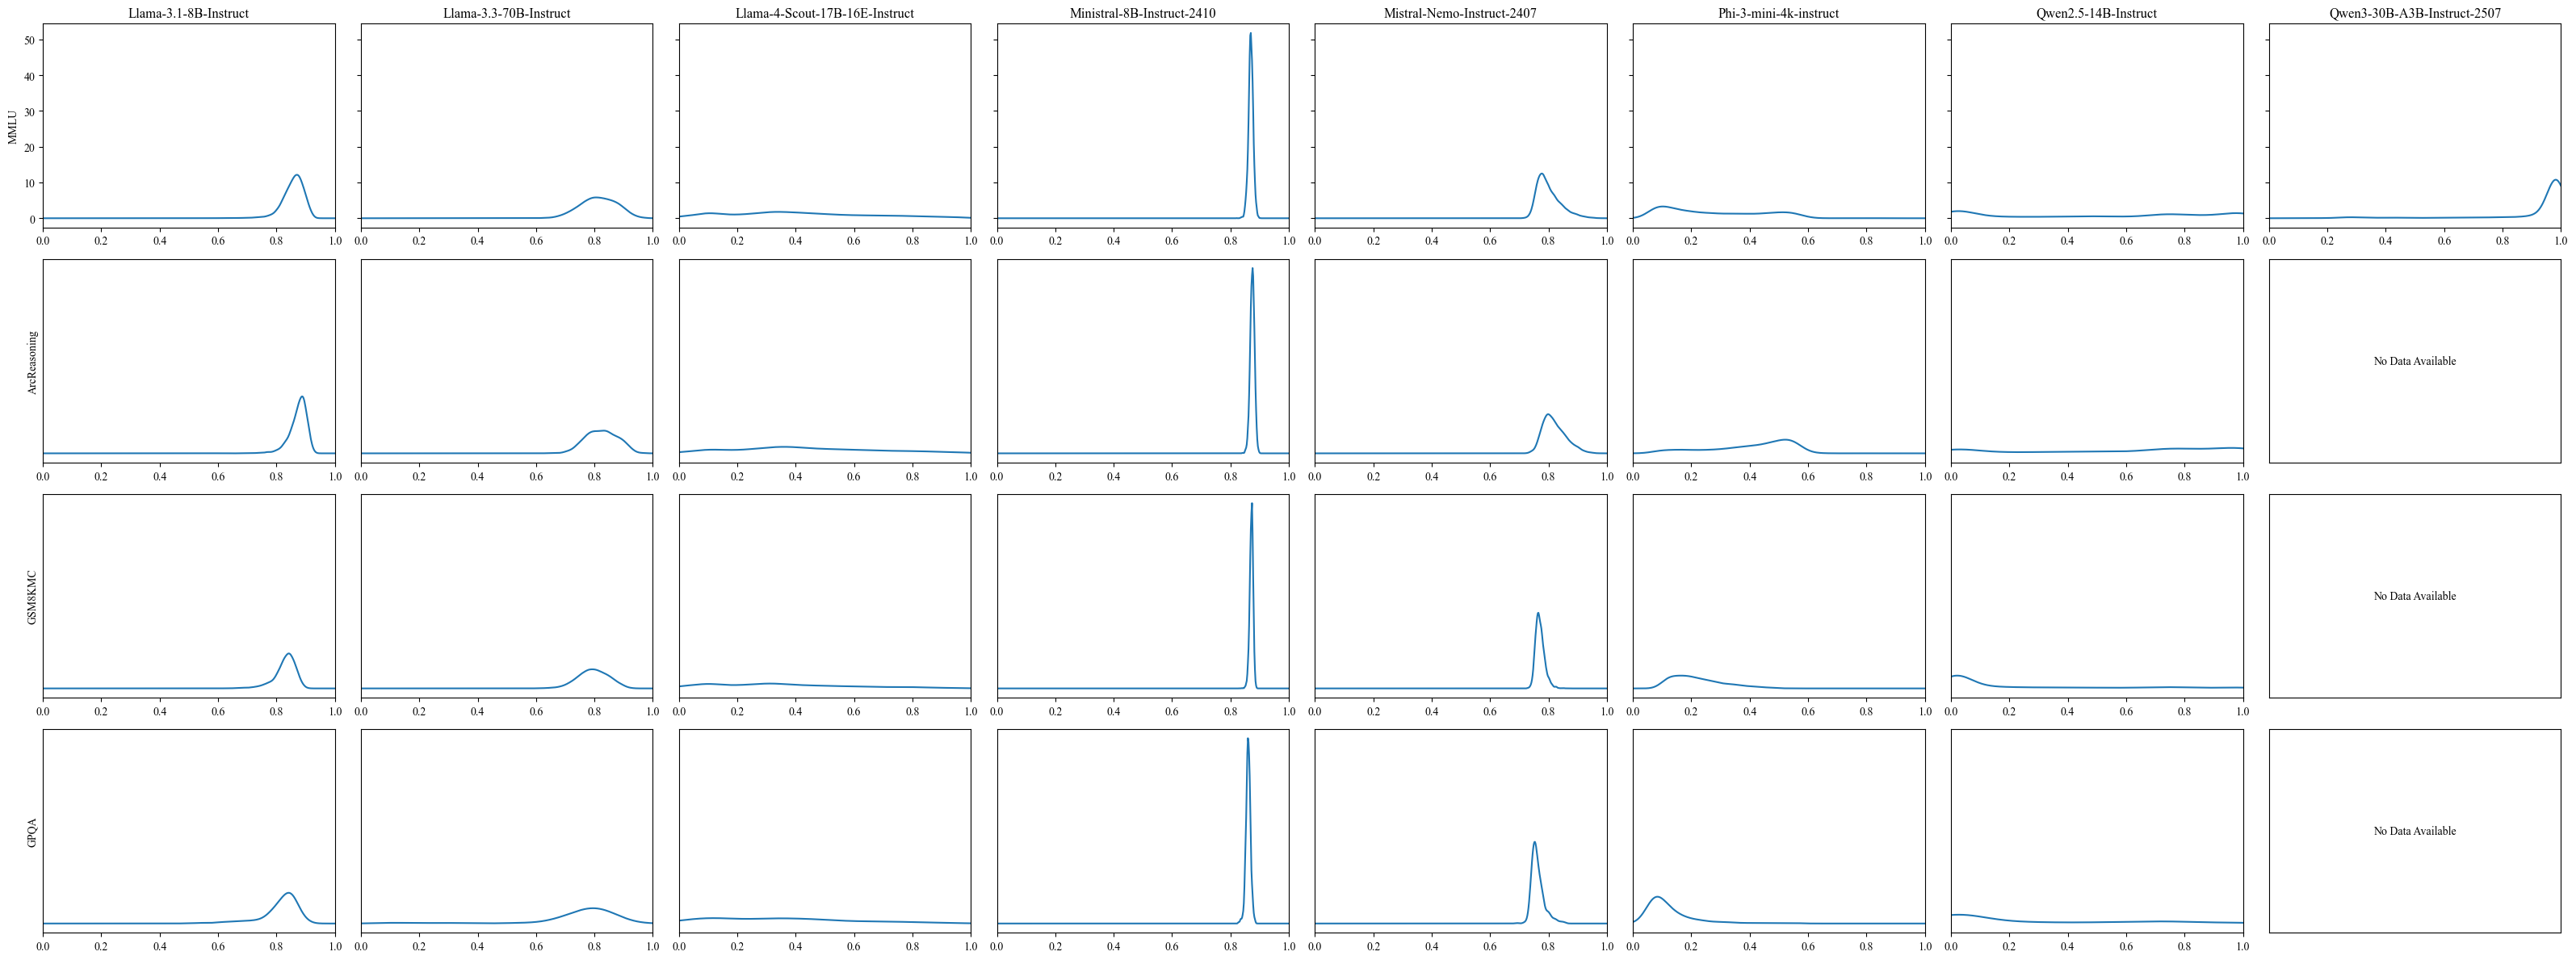

In [45]:
# Self-contained plotting cell
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Assumes `dataframes` is the nested dict from before:
# dataframes[dataset_id][model_id] = merged_df

dataset_ids = list(dataframes.keys())
model_ids = sorted({m for d in dataframes.values() for m in d.keys()})

n_rows = len(dataset_ids)
n_cols = len(model_ids)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharey="row",
    squeeze=False,
)

x_grid = np.linspace(0.0, 1.0, 500)

for i, dataset_id in enumerate(dataset_ids):
    for j, model_id in enumerate(model_ids):
        #print("Model", model_id)
        ax = axes[i, j]

        df = dataframes.get(dataset_id, {}).get(model_id)

        if df is None or "internal_confidence" not in df:
            ax.text(
                0.5, 0.5, "No Data Available",
                ha="center", va="center", transform=ax.transAxes
            )
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            values = df["internal_confidence"].dropna().to_numpy()

            if len(values) == 0:
                ax.text(
                    0.5, 0.5, "No Data Available",
                    ha="center", va="center", transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                kde = gaussian_kde(values, bw_method="scott")
                y = kde(x_grid)
                ax.plot(x_grid, y)
                ax.set_xlim(0.0, 1.0)

        if i == 0:
            ax.set_title(model_id)
        if j == 0:
            ax.set_ylabel(dataset_id)

plt.tight_layout()
plt.show()


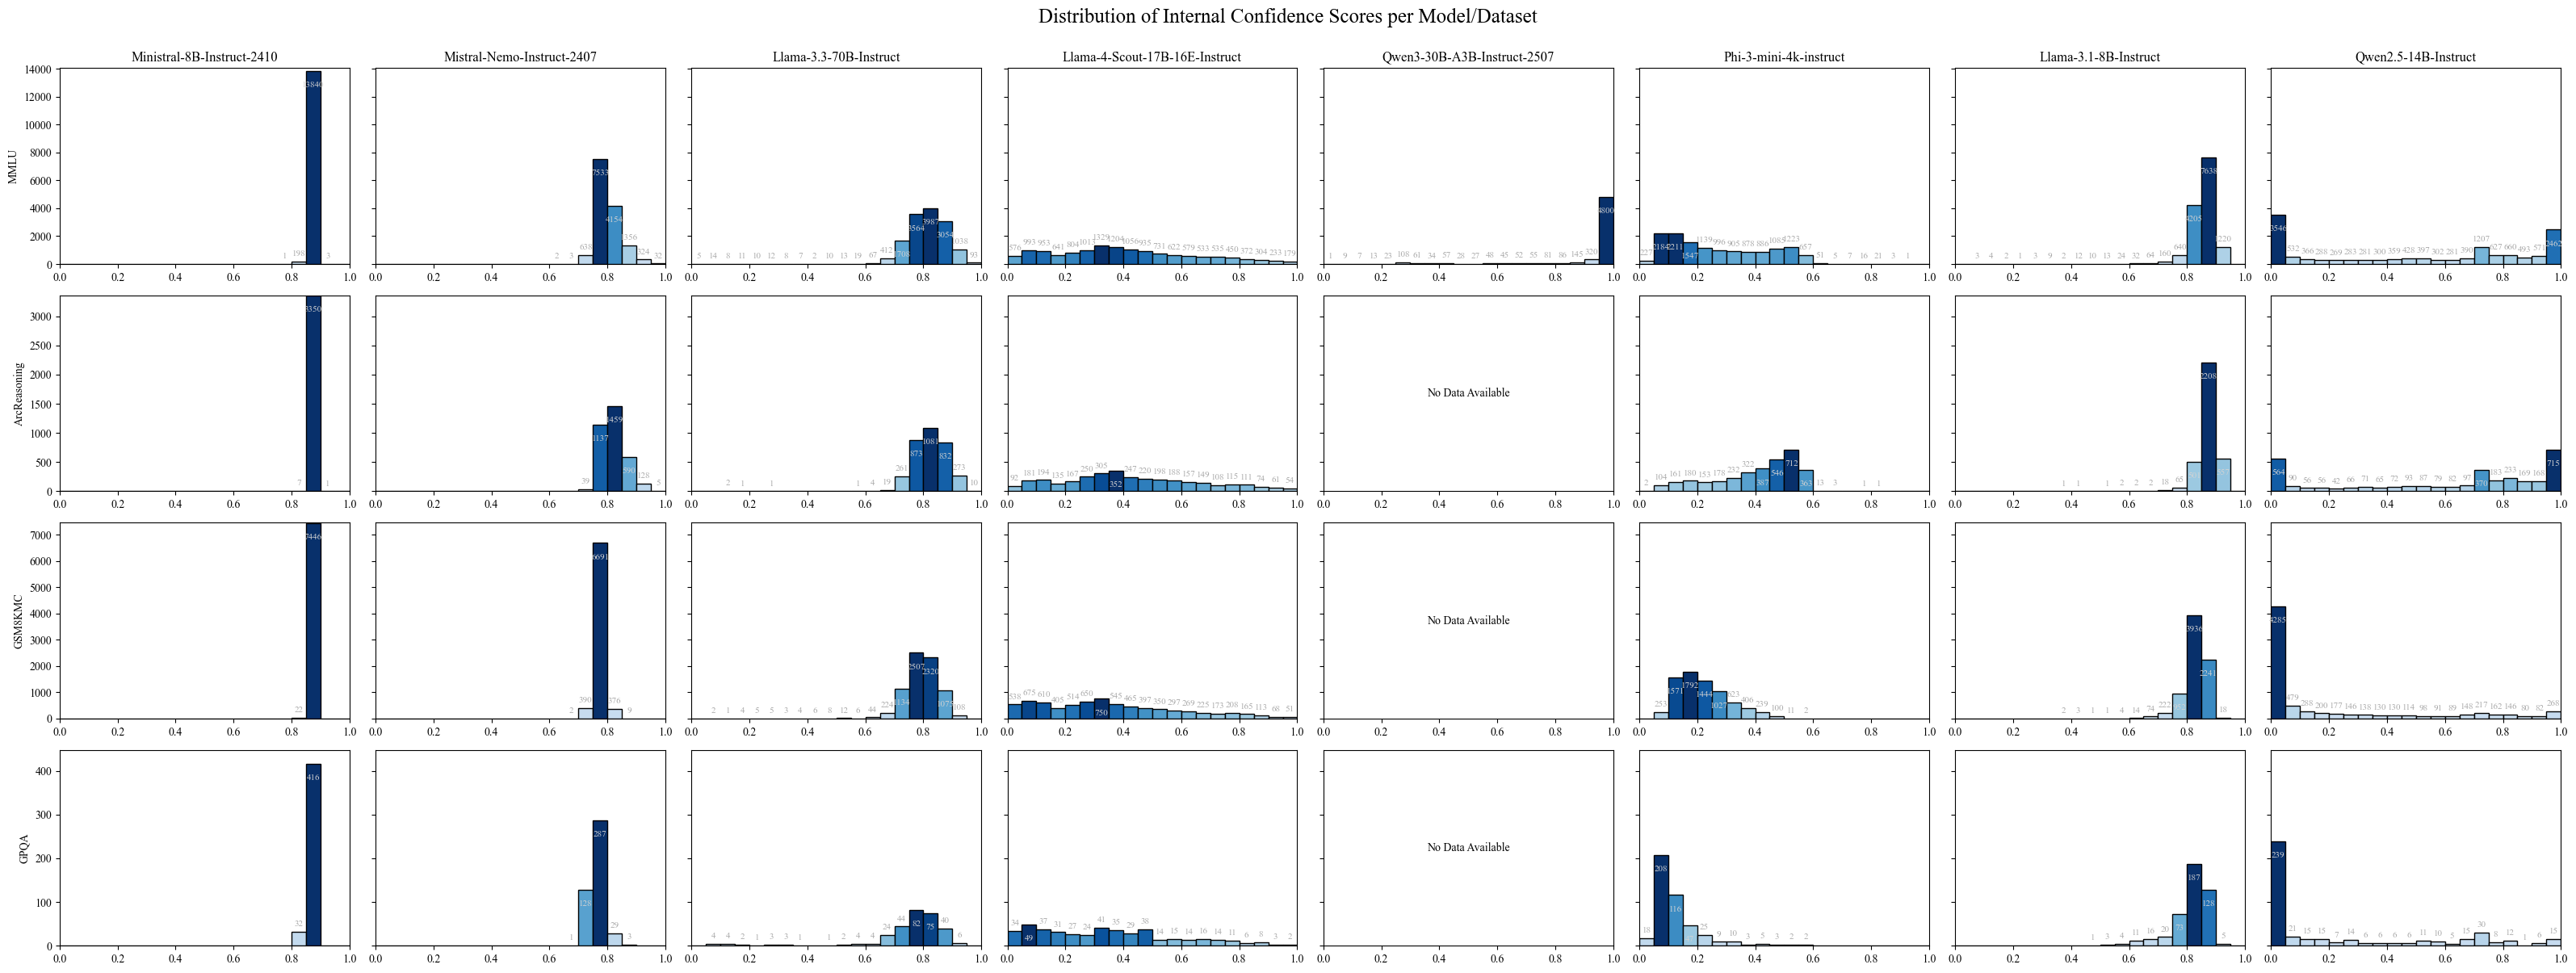

In [91]:
# Self-contained plotting cell
import matplotlib.pyplot as plt
import numpy as np

# Assumes `dataframes` is the nested dict from before:
# dataframes[dataset_id][model_id] = merged_df

dataset_ids = list(dataframes.keys())
model_ids = [m['id'] for m in models]

n_rows = len(dataset_ids)
n_cols = len(model_ids)

# =========================
# PRECOMPUTE ROW-WISE Y-LIMITS
# =========================
row_max_total_items = {}

for dataset_id in dataset_ids:
    max_items = 0
    for model_id in model_ids:
        df = dataframes.get(dataset_id, {}).get(model_id)
        if df is not None and "internal_confidence" in df:
            count = df["internal_confidence"].dropna().shape[0]
            max_items = max(max_items, count)
    row_max_total_items[dataset_id] = max_items

# =========================
# FIGURE SETUP
# =========================
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharey="row",
    squeeze=False,
)

# Histogram parameters
n_bins = 20
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

cmap = plt.colormaps["Blues"]

# =========================
# PLOTTING
# =========================
for i, dataset_id in enumerate(dataset_ids):
    row_ylim = row_max_total_items[dataset_id]

    for j, model_id in enumerate(model_ids):
        ax = axes[i, j]

        # Ensure consistent axes for ALL plots (even empty ones)
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0, row_ylim)

        # Show y-axis ONLY on first column (never delete ticks!)
        if j == 0:
            ax.set_ylabel(dataset_id)
            ax.tick_params(axis="y", labelleft=True)
        else:
            ax.tick_params(axis="y", labelleft=False)

        df = dataframes.get(dataset_id, {}).get(model_id)

        if df is None or "internal_confidence" not in df:
            ax.text(
                0.5, 0.5, "No Data Available",
                ha="center", va="center",
                transform=ax.transAxes
            )
            continue

        values = df["internal_confidence"].dropna().to_numpy()

        if len(values) == 0:
            ax.text(
                0.5, 0.5, "No Data Available",
                ha="center", va="center",
                transform=ax.transAxes
            )
            continue

        # Compute histogram
        counts, _ = np.histogram(values, bins=bin_edges)

        # Normalize counts for color intensity
        max_count = counts.max()
        if max_count > 0:
            norm_counts = counts / max_count
        else:
            norm_counts = np.zeros_like(counts)

        colors = [cmap(c * 0.8 + 0.2) for c in norm_counts]

        # Plot bars
        bars = ax.bar(
            bin_centers,
            counts,
            width=bin_width,
            color=colors,
            edgecolor="black",
            align="center"
        )

        # Annotate bin counts
        for bar, count in zip(bars, counts):
            if count == 0:
                continue

            height = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2

            if height > 0.1 * row_ylim:
                y = height - 0.05 * row_ylim
                va = "top"
                color = "lightgrey"
            else:
                y = height + 0.02 * row_ylim
                va = "bottom"
                color = "darkgrey"

            ax.text(
                x, y, str(count),
                ha="center",
                va=va,
                fontsize=8,
                color=color
            )

        if i == 0:
            ax.set_title(model_id)

# Shared x-axis ticks (bottom row only)
for ax in axes[-1]:
    ax.set_xticks(np.arange(0.0, 1.1, 0.2))

fig.suptitle("Distribution of Internal Confidence Scores per Model/Dataset", fontsize=18, y=1.00)

for ext in [".png", ".svg", ".pdf"]:
    plt.savefig( resources_dir / "figures" / ("internal_confidence_distribution" + ext), bbox_inches="tight")

plt.tight_layout()
plt.show()

## Calibration

In [101]:
def plot_empty(ax, message="No Data Available"):
    """
    Displays a placeholder plot with a light grey background and a centered message.

    Args:
        ax (matplotlib.axes.Axes): The axes to plot onto.
        message (str): The message to display in the center.
    """
    ax.set_facecolor("#f0f0f0")  # Light grey background
    ax.text(0.5, 0.5, message,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=14,
            color="#555555",  # Darker grey text
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_frame_on(False)

In [134]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import brier_score_loss

def compute_metrics(df):
    """
    Returns a dict of scalar metrics for the table.
    Extend this by adding new keys.
    """
    accuracy = df["is_correct"].mean()

    # AUROC over correctness vs confidence
    try:
        auroc = roc_auc_score(df["is_correct"], df["internal_confidence"])
    except ValueError:
        auroc = np.nan

    # Brier
    y_true = df["is_correct"].astype(int)            # convert True/False → 1/0
    y_prob = df["internal_confidence"]              # predicted probability/confidence

    brier_score = brier_score_loss(y_true, y_prob)

    # Quantiles
    quantiles = [0, 0.25, 0.5, 0.75, 1.0]
    quantile_values = df["internal_confidence"].quantile(quantiles).round(2).tolist()

    # ECE assumed precomputed elsewhere OR recomputed here
    # Placeholder: replace with your existing ECE computation

    bin_confidences, bucket_accuracies, bucket_counts = calculate_calibration_data(
        df["is_correct"].tolist(),
        df["internal_confidence"].tolist(),
        n_buckets=15
    )
    ece = calculate_ece(bin_confidences, bucket_accuracies, bucket_counts)

    return {
        "Accuracy": accuracy,
        "ECE": ece,
        "AUROC": auroc,
        "Brier Score": brier_score,
        "Quantiles[0, 0.25, 0.5, 0.75, 1]": str(quantile_values)
    }

In [127]:
def plot_metrics_table(ax, metrics, fontsize=10):
    """
    Renders a simple 2-column table: metric name | value
    """
    ax.axis("off")

    rows = [[k, f"{v:.4f}" if np.isfinite(v) else "–"] for k, v in metrics.items()]

    table = ax.table(
        cellText=rows,
        colLabels=["Metric", "Value"],
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.3)

In [131]:
def plot_calibration_with_table(df, ax_plot, ax_table, calibration_data_fn):
    """
    Renders a calibration plot (square, full width) with a table beneath.
    """

    # ---- Calibration plot ----
    if df is None or len(df) == 0:
        plot_empty(ax_plot)
    else:
        bin_confidences, bucket_accuracies, bucket_counts, ece = calibration_data_fn(df)
        plot_calibration_curve(
            bin_confidences,
            bucket_accuracies,
            bucket_counts,
            ax=ax_plot,
            ece=ece,
            total_item_count=len(df),
            xlabel=None,
            ylabel=None,
        )

    # Enforce square aspect
    ax_plot.set_aspect(1, adjustable="box")

    # ---- Metrics table ----
    ax_table.axis("off")
    if df is None or len(df) == 0:
        return

    metrics = compute_metrics(df)
    rows = [
        [k, f"{v:.4f}" if isinstance(v, (int, float)) and np.isfinite(v) else str(v) if isinstance(v, str) else "–"]
        for k, v in metrics.items()
    ]
    table = ax_table.table(
        cellText=rows,
        colLabels=["Metric", "Value"],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)


In [160]:
def plot_calibration_grid(dataframes, dataset_ids, model_ids, calibration_data_fn, plot_title=None):
    """
    Generates a grid: rows = datasets, columns = models.
    Each dataset row has 2 rows in the grid: calibration (square) + table.
    """

    n_datasets = len(dataset_ids)
    n_models = len(model_ids)

    # Figure size: width ~ n_models * 5, height ~ n_datasets * (5 + 1.5) for table
    figsize = (n_models * 5, n_datasets * 7)

    # Height ratios: calibration plot gets 0.85, table gets 0.15
    height_ratios = []
    for _ in range(n_datasets):
        height_ratios.extend([0.83, 0.22])

    fig, axes = plt.subplots(
        n_datasets * 2,
        n_models,
        figsize=figsize,
        gridspec_kw={"height_ratios": height_ratios, "hspace": 0.05, "wspace": 0.15},
    )

    # Ensure axes is 2D array
    if n_datasets == 1 and n_models == 1:
        axes = np.array([[axes]])
    elif n_datasets == 1:
        axes = np.array([axes])
    elif n_models == 1:
        axes = axes.reshape(n_datasets * 2, 1)

    for i, dataset in enumerate(dataset_ids):
        for j, model in enumerate(model_ids):
            dataset_id = dataset['id']
            model_id = model['id']
            ax_plot = axes[2 * i, j]
            ax_table = axes[2 * i + 1, j]

            df = dataframes.get(dataset_id, {}).get(model_id)
            plot_calibration_with_table(df, ax_plot, ax_table, calibration_data_fn)

            # Column headers (models)
            if i == 0:
                ax_plot.set_title(model['shortname'], fontsize=18, y=1.03,fontweight='bold')

            # Row labels (datasets)
            if j == 0:
                ax_plot.set_ylabel(dataset_id, fontsize=18, labelpad=10,fontweight='bold')

    # Figure title
    if plot_title:
        fig.suptitle(plot_title, fontsize=24, y=0.9,fontweight='bold')
    plt.tight_layout()
    return plt

C:\Users\PHMU3\AppData\Local\Temp\ipykernel_18616\433091448.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


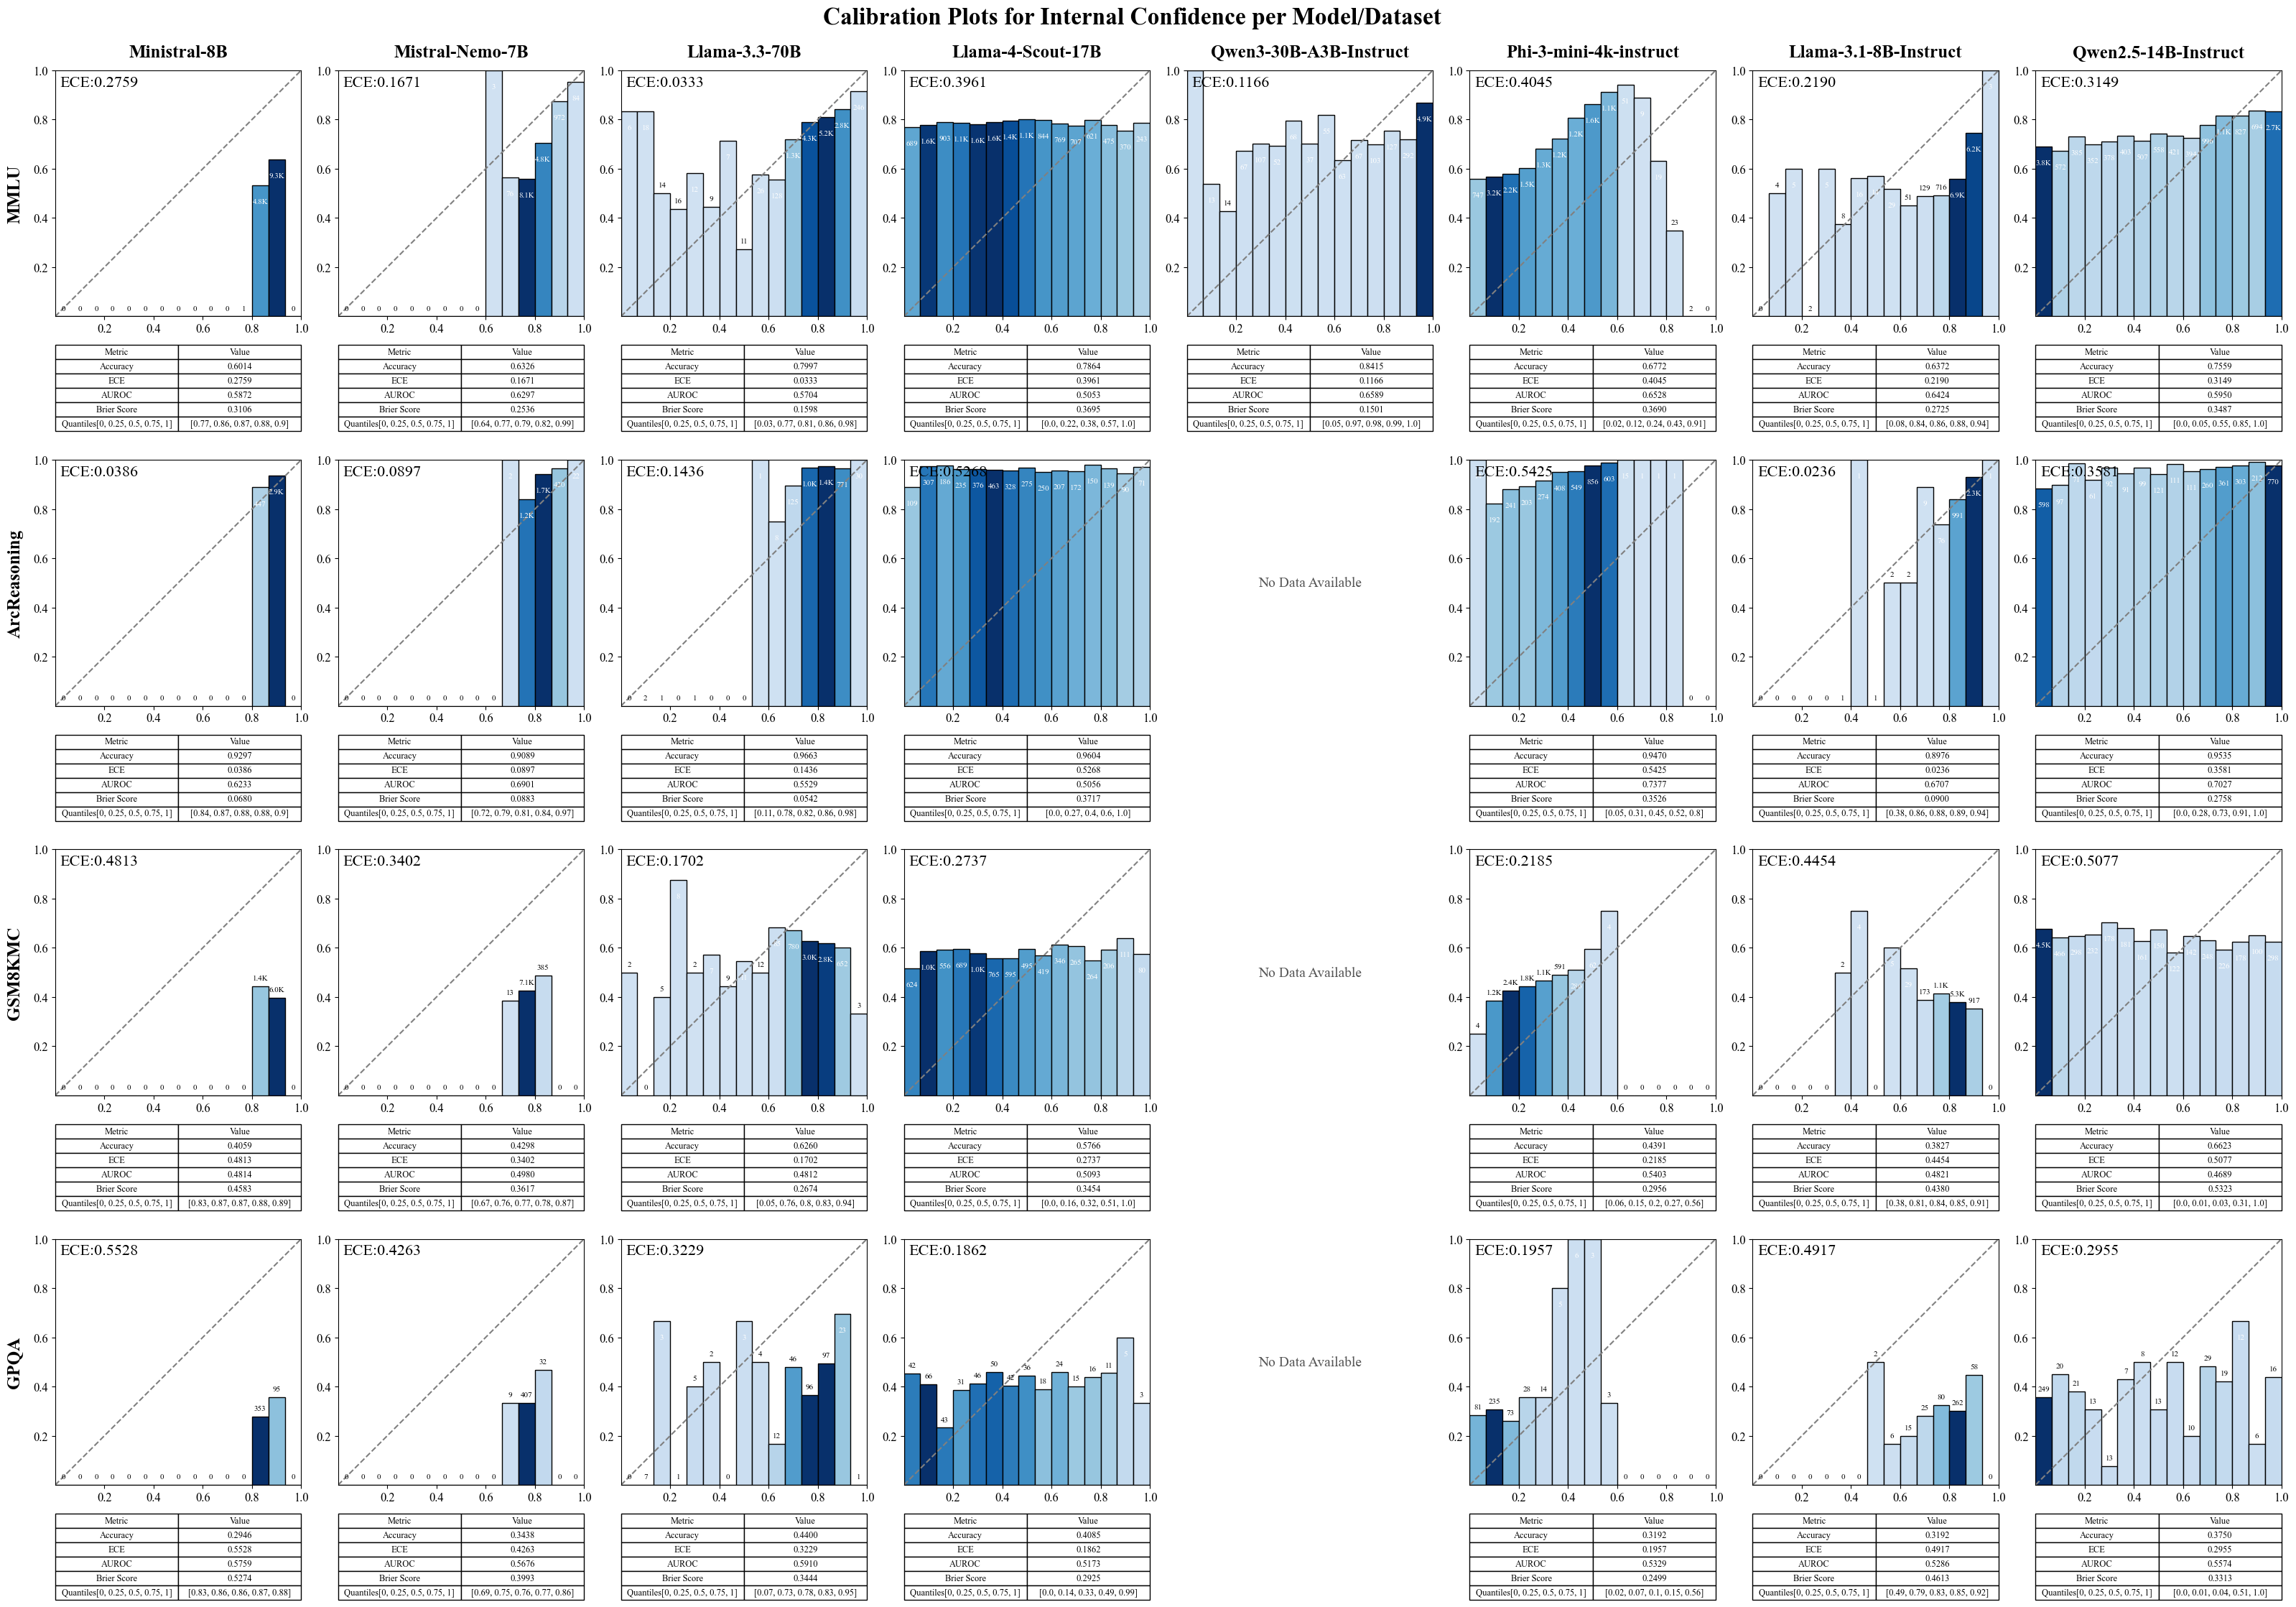

In [161]:
def calibration_data_fn(df):
    bin_confidences, bucket_accuracies, bucket_counts = calculate_calibration_data(
        df["is_correct"].tolist(),
        df["internal_confidence"].tolist(),
        n_buckets=15
    )
    ece = calculate_ece(bin_confidences, bucket_accuracies, bucket_counts)
    return bin_confidences, bucket_accuracies, bucket_counts, ece

plt = plot_calibration_grid(dataframes, datasets, models, calibration_data_fn, plot_title="Calibration Plots for Internal Confidence per Model/Dataset")
for ext in [".png", ".svg", ".pdf"]:
    plt.savefig( resources_dir / "figures" / ("calibration_plots" + ext), bbox_inches="tight")
plt.show()

# Model Cascading Plots
> Figure 6: Left: We use estimated Internal Confidence to decide whether to invoke RAG. If the Internal Confidence exceeds a threshold, the model answers the query using its parametric knowledge. Otherwise, it relies on external knowledge. The plot shows the accuracy of Phi-3.8B on the TriviaQA dataset under this setting. Right: We implement a model cascading setting with Phi-3.8B (small) and Llama-8B (large) on the TriviaQA dataset. The Internal Confidence of the smaller model determines whether it answers the query or defers to the larger model when confidence is low. The green lines indicate the baseline accuracy achieved by the simple model or complex model.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#small_model = next(m for m in models if m['name'] == 'microsoft/Phi-3-mini-4k-instruct')
small_model = next(m for m in models if m['name'] == 'mistralai/Ministral-8B-Instruct-2410')
#large_model = next(m for m in models if m['name'] == 'meta-llama/Llama-3.1-8B-Instruct')
large_model = next(m for m in models if m['name'] == 'meta-llama/Llama-4-Scout-17B-16E-Instruct')
dataset = datasets_by_id['MMLU']

df_small = dataframes[dataset['id']][small_model['id']]
df_large = dataframes[dataset['id']][large_model['id']]

# Merge on id with clear prefixes
merged = (
    df_small.merge(
        df_large,
        on="id",
        how="inner",
        suffixes=("_small", "_large")
    )
)

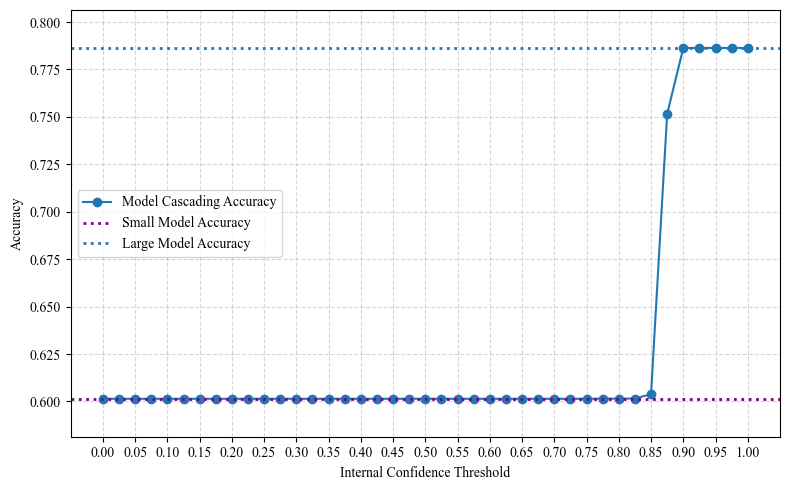

In [20]:
# Generate cascading accuracy data
thresholds = np.arange(0.0, 1.01, 0.025)
cascading_accuracies = []

for t in thresholds:
    # Choose correctness based on confidence threshold
    chosen_correctness = np.where(
        merged["internal_confidence_small"] >= t,
        merged["is_correct_small"],
        merged["is_correct_large"],
    )

    accuracy = chosen_correctness.mean()
    cascading_accuracies.append(accuracy)

# Convert to numpy array for convenience
cascading_accuracies = np.array(cascading_accuracies)

# Baseline accuracies
small_model_accuracy = merged["is_correct_small"].mean()
large_model_accuracy = merged["is_correct_large"].mean()

# Plot
plt.figure(figsize=(8, 5))

# Cascading curve
plt.plot(
    thresholds,
    cascading_accuracies,
    marker="o",
    linestyle="-",
    label="Model Cascading Accuracy",
)

# Baseline accuracies
plt.axhline(
    small_model_accuracy,
    linestyle=":",
    linewidth=2,
    label="Small Model Accuracy",
    color="purple"
)
plt.axhline(
    large_model_accuracy,
    linestyle=":",
    linewidth=2,
    label="Large Model Accuracy",
)

# Axis limits
y_min = min(cascading_accuracies.min(), small_model_accuracy, large_model_accuracy)
y_max = max(cascading_accuracies.max(), small_model_accuracy, large_model_accuracy)
plt.ylim(y_min - 0.02, y_max + 0.02)

# Labels and ticks
plt.xlabel("Internal Confidence Threshold")
plt.ylabel("Accuracy")
tick_start = np.floor(thresholds.min() / 0.05) * 0.05
tick_end = np.ceil(thresholds.max() / 0.05) * 0.05
xticks = np.arange(tick_start, tick_end + 1e-8, 0.05)
plt.xticks(xticks, [f"{x:.2f}" for x in xticks])
#plt.xticks(thresholds, rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Random

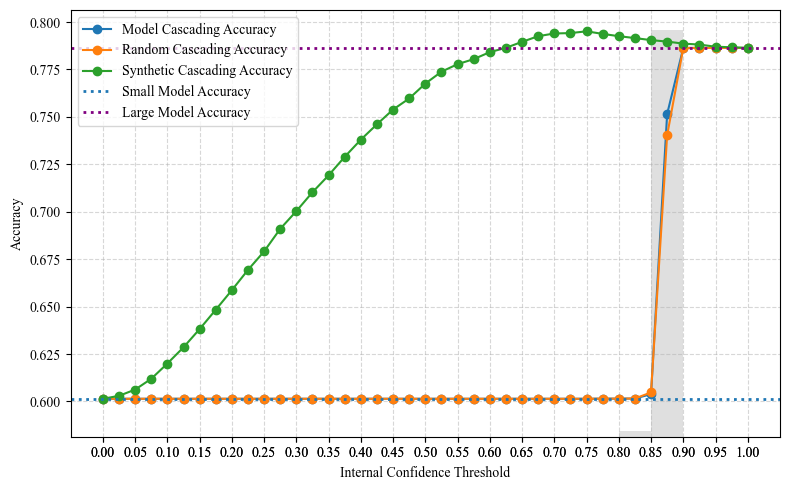

In [21]:
# Generate random cascading accuracy data
rng = np.random.default_rng(seed=27)  # seed for reproducibility

# synthetic good confidence scores
# Distribution parameters
# mean = alpha / (alpha + beta)
# Start with original correctness
misclassification_rate = 0.10
# Start with original correctness
flipped_correctness = merged["is_correct_small"].copy()
# Generate mask of rows to flip
flip_mask = rng.random(len(merged)) < misclassification_rate
# Flip selected rows
flipped_correctness.loc[flip_mask] = (~flipped_correctness.loc[flip_mask]).astype(bool)

correct_alpha, correct_beta = 4,2      # mean ≈ 0.8
incorrect_alpha, incorrect_beta = 2,4  # mean ≈ 0.2

merged["synthetic_confidence"] = np.where(
    flipped_correctness,
    rng.beta(correct_alpha, correct_beta, size=len(merged)),
    rng.beta(incorrect_alpha, incorrect_beta, size=len(merged)),
)

synthetic_cascading_accuracies = []

for t in thresholds:
    # Choose correctness based on confidence threshold
    chosen_correctness = np.where(
        merged["synthetic_confidence"] >= t,
        merged["is_correct_small"],
        merged["is_correct_large"],
    )

    accuracy = chosen_correctness.mean()
    synthetic_cascading_accuracies.append(accuracy)

# Convert to numpy array for convenience
synthetic_cascading_accuracies = np.array(synthetic_cascading_accuracies)

# Random

# merged["random_confidence"] = rng.uniform(0.0, 1.0, size=len(merged))
merged["random_confidence"] = (
    merged["internal_confidence_small"]
    .sample(frac=1.0, random_state=42)
    .to_numpy()
)

random_cascading_accuracies = []

for t in thresholds:
    # Choose correctness based on confidence threshold
    chosen_correctness = np.where(
        merged["random_confidence"] >= t,
        merged["is_correct_small"],
        merged["is_correct_large"],
    )

    accuracy = chosen_correctness.mean()
    random_cascading_accuracies.append(accuracy)

# Convert to numpy array for convenience
random_cascading_accuracies = np.array(random_cascading_accuracies)

# Baseline accuracies
small_model_accuracy = merged["is_correct_small"].mean()
large_model_accuracy = merged["is_correct_large"].mean()

# Plot
plt.figure(figsize=(8, 5))

# --- Background histogram (shared x, independent y) ---
ax = plt.gca()

# Create a full-size background axes that shares x but not y
ax_hist = ax.inset_axes([0, 0, 1, 1], transform=ax.transAxes, zorder=0)
ax_hist.sharex(ax)

ax_hist.hist(
    merged["internal_confidence_small"],
    bins=20,
    range=(0, 1),
    alpha=0.25,
    color="gray",
)

# Hide everything except bars
ax_hist.set_yticks([])
ax_hist.set_ylabel("")
ax_hist.tick_params(left=False, labelleft=False)
for spine in ax_hist.spines.values():
    spine.set_visible(False)

# Ensure main plot is on top
ax.set_zorder(1)
ax.patch.set_alpha(0)
# --- end background histogram ---


# Cascading curve
plt.plot(
    thresholds,
    cascading_accuracies,
    marker="o",
    linestyle="-",
    label="Model Cascading Accuracy",
)

# Random Cascading curve
plt.plot(
    thresholds,
    random_cascading_accuracies,
    marker="o",
    linestyle="-",
    label="Random Cascading Accuracy",
)

# Synthetic Cascading curve
plt.plot(
    thresholds,
    synthetic_cascading_accuracies,
    marker="o",
    linestyle="-",
    label="Synthetic Cascading Accuracy",
)


# Baseline accuracies
plt.axhline(
    small_model_accuracy,
    linestyle=":",
    linewidth=2,
    label="Small Model Accuracy",
)
plt.axhline(
    large_model_accuracy,
    linestyle=":",
    linewidth=2,
    label="Large Model Accuracy",
    color="purple",
)

# Axis limits
y_min = min(cascading_accuracies.min(), small_model_accuracy, large_model_accuracy)
y_max = max(cascading_accuracies.max(), small_model_accuracy, large_model_accuracy)
plt.ylim(y_min - 0.02, y_max + 0.02)

# Labels and ticks
plt.xlabel("Internal Confidence Threshold")
plt.ylabel("Accuracy")
tick_start = np.floor(thresholds.min() / 0.05) * 0.05
tick_end = np.ceil(thresholds.max() / 0.05) * 0.05
xticks = np.arange(tick_start, tick_end + 1e-8, 0.05)
plt.xticks(xticks, [f"{x:.2f}" for x in xticks])
#plt.xticks(thresholds, rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

for ext in [".png", ".svg", ".pdf"]:
    plt.savefig( resources_dir / "figures" / ("model_cascading_ministral" + ext), bbox_inches="tight")

plt.tight_layout()
plt.show()

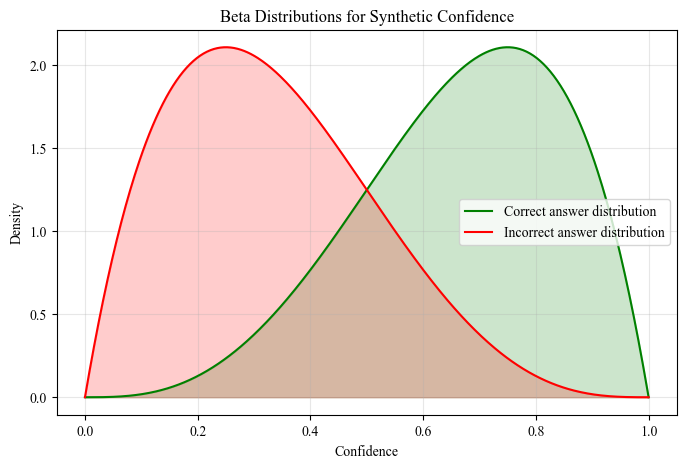

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameters for Beta distributions
correct_alpha, correct_beta = 4,2   # mean ≈ 0.8
incorrect_alpha, incorrect_beta = 2,4  # mean ≈ 0.2

# X-axis: values from 0 to 1
x = np.linspace(0, 1, 500)

# PDF of Beta distributions
pdf_correct = beta.pdf(x, correct_alpha, correct_beta)
pdf_incorrect = beta.pdf(x, incorrect_alpha, incorrect_beta)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, pdf_correct, label="Correct answer distribution", color="green")
plt.plot(x, pdf_incorrect, label="Incorrect answer distribution", color="red")
plt.fill_between(x, 0, pdf_correct, color="green", alpha=0.2)
plt.fill_between(x, 0, pdf_incorrect, color="red", alpha=0.2)
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.title("Beta Distributions for Synthetic Confidence")
plt.legend()
plt.grid(alpha=0.3)
for ext in [".png", ".svg", ".pdf"]:
    plt.savefig( resources_dir / "figures" / ("correct_incorrect_distributions" + ext), bbox_inches="tight")

plt.show()

In [80]:
from sklearn.metrics import roc_auc_score

# Ensure binary labels
y_true = merged["is_correct_small"].astype(int)

# Dictionary of confidence columns to evaluate
confidence_columns = ["internal_confidence_small", "random_confidence", "synthetic_confidence"]

# Compute AUROC for each
for col in confidence_columns:
    y_score = merged[col]
    auroc = roc_auc_score(y_true, y_score)
    print(f"AUROC for {col}: {auroc:.4f}")

AUROC for internal_confidence_small: 0.6528
AUROC for random_confidence: 0.5069
AUROC for synthetic_confidence: 0.8222
